# Data Retrieval

This may not work on windows so just use the extracted NIPS papers data from the __`nipstxt/`__ folder present in the same directory as this notebook which already has the data pre-downloaded and extracted

In [43]:
 # !wget https://cs.nyu.edu/~roweis/data/nips12raw_str602.tgz

# Data Extraction

In [44]:
# !tar -xzf nips12raw_str602.tgz

# Load and Pre-process Data

In [1]:
import os
import numpy as np
import pandas as pd

DATA_PATH = 'nipstxt/'
print(os.listdir(DATA_PATH))

['nips04', 'nips07', 'nips05', 'nips10', 'nips02', 'MATLAB_NOTES', 'README_yann', 'idx', 'nips00', 'nips12', 'nips01', 'nips03', 'nips11', 'nips09', 'RAW_DATA_NOTES', 'nips06', 'orig', 'nips08']


In [2]:
folders = ["nips{0:02}".format(i) for i in range(0,13)]
# folders = ['test_data']
# Read all texts into a list.
papers = []
for folder in folders:
    file_names = os.listdir(DATA_PATH + folder)
#    file_names = os.listdir(folder)
    for file_name in file_names:
#        with open(folder + '/' + file_name, encoding='utf-8', errors='ignore', mode='r+') as f:
        with open(DATA_PATH + folder + '/' + file_name, encoding='utf-8', errors='ignore', mode='r+') as f:
            data = f.read()
        papers.append(data)
len(papers)

1740

In [3]:
print(papers[0][:1000])

474 
OPTIMIZATION WITH ARTIFICIAL NEURAL NETWORK SYSTEMS: 
A MAPPING PRINCIPLE 
AND 
A COMPARISON TO GRADIENT BASED METHODS * 
Harrison MonFook Leong 
Research Institute for Advanced Computer Science 
NASA Ames Research Center 230-5 
Moffett Field, CA, 94035 
ABSTRACT 
General formulae for mapping optimization problems into systems of ordinary differential 
equations associated with artificial neural networks are presented. A comparison is made to optim- 
ization using gradient-search methods. The performance measure is the settling time from an initial 
state to a target state. A simple analytical example illustrates a situation where dynamical systems 
representing artificial neural network methods would settle faster than those representing gradient- 
search. Settling time was investigated for a more complicated optimization problem using com- 
puter simulations. The problem was a simplified version of a problem in medical imaging: deter- 
mining loci of cerebral activity from elect

## Basic Text Wrangling

In [4]:
%%time
import nltk

stop_words = nltk.corpus.stopwords.words('english')
wtk = nltk.tokenize.RegexpTokenizer(r'\w+')
wnl = nltk.stem.wordnet.WordNetLemmatizer()

def normalize_corpus(papers):
    norm_papers = []
    for paper in papers:
        paper = paper.lower()
        paper_tokens = [token.strip() for token in wtk.tokenize(paper)]
        paper_tokens = [wnl.lemmatize(token) for token in paper_tokens if not token.isnumeric()]
        paper_tokens = [token for token in paper_tokens if len(token) > 1]
        paper_tokens = [token for token in paper_tokens if token not in stop_words]
        paper_tokens = list(filter(None, paper_tokens))
        if paper_tokens:
            norm_papers.append(paper_tokens)
            
    return norm_papers
    
norm_papers = normalize_corpus(papers)
print(len(norm_papers))

1740
CPU times: user 10.7 s, sys: 923 ms, total: 11.6 s
Wall time: 10.6 s


In [5]:
print(norm_papers[0][:50])

['optimization', 'artificial', 'neural', 'network', 'system', 'mapping', 'principle', 'comparison', 'gradient', 'based', 'method', 'harrison', 'monfook', 'leong', 'research', 'institute', 'advanced', 'computer', 'science', 'nasa', 'ames', 'research', 'center', 'moffett', 'field', 'ca', 'abstract', 'general', 'formula', 'mapping', 'optimization', 'problem', 'system', 'ordinary', 'differential', 'equation', 'associated', 'artificial', 'neural', 'network', 'presented', 'comparison', 'made', 'optim', 'ization', 'using', 'gradient', 'search', 'method', 'performance']


# Text Representation with Feature Engineering

In [6]:
import gensim
# , delimiter=b'_'
bigram = gensim.models.Phrases(norm_papers, min_count=20, threshold=20) # higher threshold fewer phrases.
bigram_model = gensim.models.phrases.Phraser(bigram)

print(bigram_model[norm_papers[0]][:50])

['optimization', 'artificial_neural', 'network', 'system', 'mapping', 'principle', 'comparison', 'gradient', 'based', 'method', 'harrison', 'monfook', 'leong', 'research_institute', 'advanced', 'computer_science', 'nasa_ames', 'research_center', 'moffett', 'field', 'ca_abstract', 'general', 'formula', 'mapping', 'optimization_problem', 'system', 'ordinary_differential', 'equation', 'associated', 'artificial_neural', 'network', 'presented', 'comparison', 'made', 'optim', 'ization', 'using', 'gradient', 'search', 'method', 'performance', 'measure', 'settling_time', 'initial', 'state', 'target', 'state', 'simple', 'analytical', 'example']


In [7]:
norm_corpus_bigrams = [bigram_model[doc] for doc in norm_papers]

# Create a dictionary representation of the documents.
dictionary = gensim.corpora.Dictionary(norm_corpus_bigrams)
print('Sample word to number mappings:', list(dictionary.items())[:15])
print('Total Vocabulary Size:', len(dictionary))

Sample word to number mappings: [(0, '100x'), (1, '111ustration'), (2, '2a'), (3, '2b'), (4, '2gvl'), (5, '2l23'), (6, '2t0'), (7, '3a'), (8, '3b'), (9, '3fv'), (10, '3gi'), (11, '3t'), (12, '48o'), (13, '6a'), (14, '6als')]
Total Vocabulary Size: 78955


In [8]:
# Filter out words that occur less than 20 documents, or more than 50% of the documents.
# dictionary.filter_extremes(no_below=1, no_above=0.8)
print('Total Vocabulary Size:', len(dictionary))

Total Vocabulary Size: 78955


In [9]:
# Transforming corpus into bag of words vectors
bow_corpus = [dictionary.doc2bow(text) for text in norm_corpus_bigrams]
print(bow_corpus[1][:50])

[(2, 1), (50, 15), (51, 1), (52, 2), (57, 17), (58, 1), (59, 1), (68, 3), (70, 1), (79, 1), (80, 1), (81, 1), (92, 2), (96, 1), (99, 11), (115, 1), (121, 1), (124, 1), (126, 1), (128, 1), (130, 4), (137, 1), (145, 1), (156, 1), (159, 1), (172, 3), (174, 1), (182, 8), (195, 1), (199, 10), (213, 3), (214, 44), (223, 1), (254, 1), (257, 1), (258, 1), (266, 1), (270, 2), (275, 1), (279, 3), (290, 3), (305, 2), (321, 1), (341, 1), (345, 5), (358, 1), (364, 1), (381, 3), (389, 2), (390, 9)]


In [10]:
print([(dictionary[idx] , freq) for idx, freq in bow_corpus[1][:50]])

[('2a', 1), ('also', 15), ('always', 1), ('american_institute', 2), ('analysis', 17), ('analytical', 1), ('analyzed', 1), ('applied', 3), ('approach', 1), ('associated', 1), ('assumed', 1), ('assumption', 1), ('based', 2), ('becomes', 1), ('behavior', 11), ('calculated', 1), ('cannot', 1), ('case', 1), ('certain', 1), ('change', 1), ('chosen', 4), ('clear', 1), ('collection', 1), ('compare', 1), ('comparison', 1), ('computer_science', 3), ('computing', 1), ('condition', 8), ('considered', 1), ('constant', 10), ('converge', 3), ('convergence', 44), ('corresponding', 1), ('denotes', 1), ('dependent', 1), ('depends', 1), ('derived', 1), ('describe', 2), ('determines', 1), ('deviation', 3), ('different', 3), ('doe', 2), ('easily', 1), ('energy', 1), ('equation', 5), ('examine', 1), ('exist', 1), ('factor', 3), ('fig', 2), ('figure', 9)]


In [11]:
print('Total number of papers:', len(bow_corpus))

Total number of papers: 1740


# Topic Models with Latent Semantic Indexing (LSI)

In [12]:
%%time

TOTAL_TOPICS = 10
lsi_bow = gensim.models.LsiModel(bow_corpus, id2word=dictionary, num_topics=TOTAL_TOPICS,
                                 onepass=True, chunksize=1740, power_iters=1000)

CPU times: user 44min 1s, sys: 22min 43s, total: 1h 6min 45s
Wall time: 5min 3s


In [13]:
for topic_id, topic in lsi_bow.print_topics(num_topics=10, num_words=20):
    print('Topic #'+str(topic_id+1)+':')
    print(topic)
    print()

Topic #1:
0.295*"network" + 0.254*"model" + 0.212*"input" + 0.204*"learning" + 0.169*"function" + 0.154*"one" + 0.146*"data" + 0.145*"system" + 0.139*"algorithm" + 0.138*"output" + 0.128*"time" + 0.124*"using" + 0.123*"wa" + 0.120*"set" + 0.120*"weight" + 0.118*"two" + 0.118*"unit" + 0.116*"value" + 0.114*"state" + 0.113*"training"

Topic #2:
-0.581*"network" + 0.494*"model" + -0.244*"input" + -0.215*"unit" + 0.193*"data" + -0.176*"output" + -0.142*"weight" + 0.132*"algorithm" + 0.122*"state" + -0.092*"layer" + 0.092*"parameter" + -0.088*"pattern" + -0.071*"neural_network" + -0.070*"neuron" + -0.069*"hidden_unit" + 0.068*"method" + 0.064*"point" + -0.059*"net" + 0.058*"distribution" + -0.056*"training"

Topic #3:
-0.425*"model" + 0.284*"learning" + 0.281*"algorithm" + -0.279*"neuron" + -0.266*"cell" + 0.196*"function" + -0.175*"input" + -0.152*"response" + 0.133*"problem" + -0.130*"stimulus" + 0.111*"error" + 0.099*"weight" + 0.097*"training" + -0.094*"activity" + 0.093*"method" + 0.09

In [14]:
for n in range(TOTAL_TOPICS):
    print('Topic #'+str(n+1)+':')
    print('='*50)
    d1 = []
    d2 = []
    for term, wt in lsi_bow.show_topic(n, topn=20):
        if wt >= 0:
            d1.append((term, round(wt, 3)))
        else:
            d2.append((term, round(wt, 3)))

    print('Direction 1:', d1)
    print('-'*50)
    print('Direction 2:', d2)
    print('-'*50)
    print()
    

Topic #1:
Direction 1: [('network', 0.295), ('model', 0.254), ('input', 0.212), ('learning', 0.204), ('function', 0.169), ('one', 0.154), ('data', 0.146), ('system', 0.145), ('algorithm', 0.139), ('output', 0.138), ('time', 0.128), ('using', 0.124), ('wa', 0.123), ('set', 0.12), ('weight', 0.12), ('two', 0.118), ('unit', 0.118), ('value', 0.116), ('state', 0.114), ('training', 0.113)]
--------------------------------------------------
Direction 2: []
--------------------------------------------------

Topic #2:
Direction 1: [('model', 0.494), ('data', 0.193), ('algorithm', 0.132), ('state', 0.122), ('parameter', 0.092), ('method', 0.068), ('point', 0.064), ('distribution', 0.058)]
--------------------------------------------------
Direction 2: [('network', -0.581), ('input', -0.244), ('unit', -0.215), ('output', -0.176), ('weight', -0.142), ('layer', -0.092), ('pattern', -0.088), ('neural_network', -0.071), ('neuron', -0.07), ('hidden_unit', -0.069), ('net', -0.059), ('training', -0.05

In [15]:
term_topic = lsi_bow.projection.u
singular_values = lsi_bow.projection.s
topic_document = (gensim.matutils.corpus2dense(lsi_bow[bow_corpus], len(singular_values)).T / singular_values).T
term_topic.shape, singular_values.shape, topic_document.shape

((78955, 10), (10,), (10, 1740))

In [16]:
document_topics = pd.DataFrame(np.round(topic_document.T, 3),
                               columns=['T'+str(i) for i in range(1, TOTAL_TOPICS+1)])
document_topics.head(15)

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10
0,0.045,0.012,0.017,-0.009,-0.007,-0.001,-0.054,-0.042,-0.054,-0.021
1,0.019,0.029,-0.031,-0.003,0.027,-0.030,0.014,0.017,-0.010,-0.026
2,0.024,0.000,0.007,0.015,-0.046,0.023,0.003,-0.001,-0.021,-0.038
3,0.040,0.027,0.046,-0.122,0.030,0.088,-0.015,0.024,-0.009,0.015
4,0.040,-0.052,0.037,-0.036,0.029,-0.023,0.107,-0.005,-0.027,-0.004
5,0.045,0.005,-0.031,-0.011,0.001,-0.023,-0.013,0.029,-0.037,0.015
6,0.022,-0.019,-0.004,0.009,-0.003,0.009,-0.013,0.021,0.014,0.021
7,0.026,0.012,-0.018,0.030,-0.055,0.066,0.002,-0.039,-0.002,-0.070
8,0.041,0.007,-0.023,0.017,0.041,-0.020,0.017,-0.003,-0.059,0.013
9,0.028,-0.023,0.001,-0.001,-0.016,-0.015,-0.030,0.019,-0.033,-0.045


In [17]:
document_numbers = [13, 250, 500]

for document_number in document_numbers:
    top_topics = list(document_topics.columns[np.argsort(-np.absolute(document_topics.iloc[document_number].values))[:3]])
    print('Document #'+str(document_number)+':')
    print('Dominant Topics (top 3):', top_topics)
    print('Paper Summary:')
    print(papers[document_number][:500])
    print()

Document #13:
Dominant Topics (top 3): ['T3', 'T1', 'T5']
Paper Summary:
701 
DISCOVERING STRUCTURE FROM MOTION IN 
MONKEY, MAN AND MACHINE 
Ralph M. Siegel* 
The Salk Institute of Biology, La Jolla, Ca. 92037 
ABSTRACT 
The ability to obtain three-dimensional structure from visual motion is 
important for survival of human and non-human primates. Using a parallel process- 
ing model, the current work explores how the biological visual system might solve 
this problem and how the neurophysiologist might go about understanding the 
solution. 
INTRODUCTION 
Psychophysi

Document #250:
Dominant Topics (top 3): ['T2', 'T10', 'T5']
Paper Summary:
364 Jain and Waibel 
Incremental Parsing by Modular Recurrent 
Connectionist Networks 
Ajay N. Jain Alex H. Waibel 
School of Computer Science 
Carnegie Mellon University 
Pittsburgh, PA 15213 
ABSTRACT 
We present a novel, modular, recurrent connectionist network architec- 
ture which learns to robustly perform incremental parsing of complex 
sent

# Implementing LSI Topic Models from Scratch

In [18]:
td_matrix = gensim.matutils.corpus2dense(corpus=bow_corpus, num_terms=len(dictionary))
print(td_matrix.shape)
td_matrix

(78955, 1740)


array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [3., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [19]:
vocabulary = np.array(list(dictionary.values()))
print('Total vocabulary size:', len(vocabulary))
vocabulary

Total vocabulary size: 78955


array(['100x', '111ustration', '2a', ..., 'taxed', 'vwa', 'wiering'],
      dtype='<U71')

In [20]:
dictionary[0]

'100x'

In [21]:
from scipy.sparse.linalg import svds

u, s, vt = svds(td_matrix, k=TOTAL_TOPICS, maxiter=10000)
term_topic = u
singular_values = s
topic_document = vt
term_topic.shape, singular_values.shape, topic_document.shape

((78955, 10), (10,), (10, 1740))

In [22]:
tt_weights = term_topic.transpose() * singular_values[:, None]
tt_weights.shape

(10, 78955)

In [23]:
top_terms = 20
topic_key_term_idxs = np.argsort(-np.absolute(tt_weights), axis=1)[:, :top_terms]
topic_keyterm_weights = np.array([tt_weights[row, columns] 
                             for row, columns in list(zip(np.arange(TOTAL_TOPICS), topic_key_term_idxs))])
topic_keyterms = vocabulary[topic_key_term_idxs]
topic_keyterms_weights = list(zip(topic_keyterms, topic_keyterm_weights))
for n in range(TOTAL_TOPICS):
    print('Topic #'+str(n+1)+':')
    print('='*50)
    d1 = []
    d2 = []
    terms, weights = topic_keyterms_weights[n]
    term_weights = sorted([(t, w) for t, w in zip(terms, weights)], 
                          key=lambda row: -abs(row[1]))
    for term, wt in term_weights:
        if wt >= 0:
            d1.append((term, round(wt, 3)))
        else:
            d2.append((term, round(wt, 3)))

    print('Direction 1:', d1)
    print('-'*50)
    print('Direction 2:', d2)
    print('-'*50)
    print()

Topic #1:
Direction 1: [('cell', 159.514), ('algorithm', 101.251), ('pattern', 97.416), ('data', 80.152), ('unit', 66.975), ('time', 61.074), ('classifier', 60.182), ('wa', 51.073), ('word', 45.211), ('probability', 42.592)]
--------------------------------------------------
Direction 2: [('image', -157.989), ('function', -145.318), ('system', -88.304), ('input', -79.998), ('output', -73.531), ('model', -56.75), ('neural_network', -47.099), ('control', -45.394), ('learning', -44.653), ('weight', -43.074)]
--------------------------------------------------

Topic #2:
Direction 1: [('neuron', 173.005), ('learning', 151.209), ('network', 95.134), ('neural_network', 68.671), ('system', 68.164), ('training', 60.488), ('wa', 48.532), ('classifier', 42.84), ('performance', 39.657), ('time', 38.228), ('data', 37.886)]
--------------------------------------------------
Direction 2: [('unit', -236.438), ('input', -142.359), ('state', -105.607), ('function', -89.11), ('output', -63.887), ('value'

In [24]:
import pandas as pd

document_topics = pd.DataFrame(np.round(topic_document.T, 3), 
                               columns=['T'+str(i) for i in range(1, TOTAL_TOPICS+1)])
document_topics.head(15)

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10
0,-0.021,-0.054,-0.042,0.054,0.001,0.007,0.009,-0.017,0.012,0.045
1,-0.026,-0.010,0.017,-0.014,0.030,-0.027,0.003,0.031,0.029,0.019
2,-0.038,-0.021,-0.001,-0.003,-0.023,0.046,-0.015,-0.007,0.000,0.024
3,0.015,-0.009,0.024,0.015,-0.088,-0.030,0.122,-0.046,0.027,0.040
4,-0.004,-0.027,-0.005,-0.107,0.023,-0.029,0.036,-0.037,-0.052,0.040
5,0.015,-0.037,0.029,0.013,0.023,-0.001,0.011,0.031,0.005,0.045
6,0.021,0.014,0.021,0.013,-0.009,0.003,-0.009,0.004,-0.019,0.022
7,-0.070,-0.002,-0.039,-0.002,-0.066,0.055,-0.030,0.018,0.012,0.026
8,0.013,-0.059,-0.003,-0.017,0.020,-0.041,-0.017,0.023,0.007,0.041
9,-0.045,-0.033,0.019,0.030,0.015,0.016,0.001,-0.001,-0.023,0.028


In [25]:
document_numbers = [13, 250, 500]

for document_number in document_numbers:
    top_topics = list(document_topics.columns[np.argsort(-np.absolute(document_topics.iloc[document_number].values))[:3]])
    print('Document #'+str(document_number)+':')
    print('Dominant Topics (top 3):', top_topics)
    print('Paper Summary:')
    print(papers[document_number][:500])
    print()

Document #13:
Dominant Topics (top 3): ['T8', 'T10', 'T6']
Paper Summary:
701 
DISCOVERING STRUCTURE FROM MOTION IN 
MONKEY, MAN AND MACHINE 
Ralph M. Siegel* 
The Salk Institute of Biology, La Jolla, Ca. 92037 
ABSTRACT 
The ability to obtain three-dimensional structure from visual motion is 
important for survival of human and non-human primates. Using a parallel process- 
ing model, the current work explores how the biological visual system might solve 
this problem and how the neurophysiologist might go about understanding the 
solution. 
INTRODUCTION 
Psychophysi

Document #250:
Dominant Topics (top 3): ['T9', 'T1', 'T6']
Paper Summary:
364 Jain and Waibel 
Incremental Parsing by Modular Recurrent 
Connectionist Networks 
Ajay N. Jain Alex H. Waibel 
School of Computer Science 
Carnegie Mellon University 
Pittsburgh, PA 15213 
ABSTRACT 
We present a novel, modular, recurrent connectionist network architec- 
ture which learns to robustly perform incremental parsing of complex 
sent

# Topic Models with Latent Dirichlet Allocation (LDA)

In [26]:
%%time
lda_model = gensim.models.LdaModel(corpus=bow_corpus, id2word=dictionary, chunksize=1740, 
                                   alpha='auto', eta='auto', random_state=42,
                                   iterations=500, num_topics=TOTAL_TOPICS, 
                                   passes=20, eval_every=None)

CPU times: user 1min 36s, sys: 4min 4s, total: 5min 41s
Wall time: 37.8 s


In [27]:
for topic_id, topic in lda_model.print_topics(num_topics=10, num_words=20):
    print('Topic #'+str(topic_id+1)+':')
    print(topic)
    print()

Topic #1:
0.018*"neuron" + 0.014*"model" + 0.013*"cell" + 0.010*"input" + 0.008*"network" + 0.007*"pattern" + 0.006*"time" + 0.006*"activity" + 0.005*"response" + 0.005*"spike" + 0.004*"synaptic" + 0.004*"stimulus" + 0.004*"figure" + 0.004*"two" + 0.004*"one" + 0.004*"function" + 0.004*"firing" + 0.004*"wa" + 0.004*"cortical" + 0.003*"layer"

Topic #2:
0.015*"function" + 0.009*"learning" + 0.008*"algorithm" + 0.008*"state" + 0.007*"network" + 0.006*"set" + 0.006*"number" + 0.006*"one" + 0.006*"value" + 0.005*"result" + 0.005*"problem" + 0.005*"class" + 0.005*"weight" + 0.005*"time" + 0.005*"action" + 0.004*"example" + 0.004*"input" + 0.004*"neural_network" + 0.004*"ha" + 0.004*"node"

Topic #3:
0.011*"learning" + 0.010*"function" + 0.008*"algorithm" + 0.008*"model" + 0.006*"value" + 0.006*"method" + 0.005*"state" + 0.005*"parameter" + 0.005*"one" + 0.005*"error" + 0.005*"problem" + 0.005*"result" + 0.004*"using" + 0.004*"data" + 0.004*"case" + 0.004*"given" + 0.004*"equation" + 0.004*"

In [28]:
topics_coherences = lda_model.top_topics(bow_corpus, topn=20)
avg_coherence_score = np.mean([item[1] for item in topics_coherences])
print('Avg. Coherence Score:', avg_coherence_score)

Avg. Coherence Score: -0.5050655390908375


In [29]:
topics_with_wts = [item[0] for item in topics_coherences]
print('LDA Topics with Weights')
print('='*50)
for idx, topic in enumerate(topics_with_wts):
    print('Topic #'+str(idx+1)+':')
    print([(term, round(wt, 3)) for wt, term in topic])
    print()

LDA Topics with Weights
Topic #1:
[('network', 0.024), ('input', 0.013), ('learning', 0.011), ('output', 0.01), ('training', 0.009), ('unit', 0.009), ('wa', 0.007), ('weight', 0.007), ('one', 0.006), ('error', 0.006), ('pattern', 0.006), ('neural_network', 0.006), ('problem', 0.005), ('system', 0.005), ('number', 0.005), ('used', 0.005), ('task', 0.005), ('time', 0.005), ('performance', 0.005), ('algorithm', 0.005)]

Topic #2:
[('learning', 0.011), ('function', 0.01), ('algorithm', 0.008), ('model', 0.008), ('value', 0.006), ('method', 0.006), ('state', 0.005), ('parameter', 0.005), ('one', 0.005), ('error', 0.005), ('problem', 0.005), ('result', 0.005), ('using', 0.004), ('data', 0.004), ('case', 0.004), ('given', 0.004), ('equation', 0.004), ('vector', 0.004), ('distribution', 0.004), ('example', 0.004)]

Topic #3:
[('model', 0.021), ('data', 0.015), ('parameter', 0.006), ('set', 0.006), ('using', 0.006), ('network', 0.005), ('algorithm', 0.005), ('used', 0.005), ('probability', 0.00

In [30]:
print('LDA Topics without Weights')
print('='*50)
for idx, topic in enumerate(topics_with_wts):
    print('Topic #'+str(idx+1)+':')
    print([term for wt, term in topic])
    print()

LDA Topics without Weights
Topic #1:
['network', 'input', 'learning', 'output', 'training', 'unit', 'wa', 'weight', 'one', 'error', 'pattern', 'neural_network', 'problem', 'system', 'number', 'used', 'task', 'time', 'performance', 'algorithm']

Topic #2:
['learning', 'function', 'algorithm', 'model', 'value', 'method', 'state', 'parameter', 'one', 'error', 'problem', 'result', 'using', 'data', 'case', 'given', 'equation', 'vector', 'distribution', 'example']

Topic #3:
['model', 'data', 'parameter', 'set', 'using', 'network', 'algorithm', 'used', 'probability', 'one', 'variable', 'state', 'system', 'given', 'method', 'training', 'number', 'class', 'two', 'vector']

Topic #4:
['circuit', 'network', 'neuron', 'system', 'chip', 'input', 'output', 'analog', 'current', 'voltage', 'time', 'figure', 'one', 'neural_network', 'weight', 'ha', 'two', 'using', 'function', 'state']

Topic #5:
['function', 'learning', 'algorithm', 'state', 'network', 'set', 'number', 'one', 'value', 'result', 'probl

In [31]:
cv_coherence_model_lda = gensim.models.CoherenceModel(model=lda_model, corpus=bow_corpus, 
                                                      texts=norm_corpus_bigrams,
                                                      dictionary=dictionary, 
                                                      coherence='c_v')
avg_coherence_cv = cv_coherence_model_lda.get_coherence()

umass_coherence_model_lda = gensim.models.CoherenceModel(model=lda_model, corpus=bow_corpus, 
                                                         texts=norm_corpus_bigrams,
                                                         dictionary=dictionary, 
                                                         coherence='u_mass')
avg_coherence_umass = umass_coherence_model_lda.get_coherence()

perplexity = lda_model.log_perplexity(bow_corpus)

print('Avg. Coherence Score (Cv):', avg_coherence_cv)
print('Avg. Coherence Score (UMass):', avg_coherence_umass)
print('Model Perplexity:', perplexity)

Avg. Coherence Score (Cv): 0.3569106772630499
Avg. Coherence Score (UMass): -0.5050655390908374
Model Perplexity: -8.248631337569607


# LDA Models with MALLET

In [32]:
!wget http://mallet.cs.umass.edu/dist/mallet-2.0.8.zip

--2025-09-09 18:50:47--  http://mallet.cs.umass.edu/dist/mallet-2.0.8.zip
Resolving mallet.cs.umass.edu (mallet.cs.umass.edu)... 128.119.246.70
Connecting to mallet.cs.umass.edu (mallet.cs.umass.edu)|128.119.246.70|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://mallet.cs.umass.edu/dist/mallet-2.0.8.zip [following]
--2025-09-09 18:50:47--  https://mallet.cs.umass.edu/dist/mallet-2.0.8.zip
Connecting to mallet.cs.umass.edu (mallet.cs.umass.edu)|128.119.246.70|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16184794 (15M) [application/zip]
Saving to: ‘mallet-2.0.8.zip’

mallet-2.0.8.zip    100%[===================>]  15.43M  13.9MB/s    in 1.1s    

2025-09-09 18:50:48 (13.9 MB/s) - ‘mallet-2.0.8.zip’ saved [16184794/16184794]



In [33]:
!unzip -q mallet-2.0.8.zip

The following cell won't work with Gensim >= 4.x since the wrappers were removed. To add them, download an older release (e.g. 3.8.3, [https://github.com/piskvorky/gensim/releases/tag/3.8.3](https://github.com/piskvorky/gensim/releases/tag/3.8.3)) / downgrade gensim accordingly (e.g. `pip3 install "gensim==3.8.2"`) and copy `gensim-3.8.3/gensim/models/wrappers` and `gensim-3.8.3/gensim/models/deprecated` into your gensim module.

In [36]:
MALLET_PATH = 'mallet-2.0.8/bin/mallet'
from gensim.models.wrappers import LdaMallet
lda_mallet = gensim.models.wrappers.LdaMallet(mallet_path=MALLET_PATH, corpus=bow_corpus, 
                                              num_topics=TOTAL_TOPICS, id2word=dictionary,
                                              iterations=500, workers=16)

Mallet LDA: 10 topics, 4 topic bits, 1111 topic mask
Data loaded.
max tokens: 4456
total tokens: 2393192
<10> LL/token: -10.26011
<20> LL/token: -9.49309
<30> LL/token: -9.28093
<40> LL/token: -9.19325

0	5	image model object visual feature motion figure map position direction wa unit location system point region representation pixel target orientation 
1	5	training data wa classification class performance classifier system feature trained model output recognition neural_network network set speech test method result 
2	5	model data parameter distribution method variable algorithm gaussian approach estimate prior set variance density component probability space point mixture matrix 
3	5	function algorithm error result learning set case vector linear problem weight number class point bound parameter term method training optimal 
4	5	state time control system learning algorithm function action problem step model dynamic policy trajectory method optimal process controller based reinforceme

In [37]:
topics = [[(term, round(wt, 3)) 
               for term, wt in lda_mallet.show_topic(n, topn=20)] 
                   for n in range(0, TOTAL_TOPICS)]

for idx, topic in enumerate(topics):
    print('Topic #'+str(idx+1)+':')
    print([term for term, wt in topic])
    print()

Topic #1:
['image', 'object', 'model', 'visual', 'feature', 'motion', 'figure', 'position', 'direction', 'point', 'location', 'pixel', 'representation', 'wa', 'field', 'map', 'system', 'region', 'view', 'face']

Topic #2:
['training', 'classification', 'data', 'system', 'wa', 'performance', 'class', 'classifier', 'feature', 'word', 'recognition', 'neural_network', 'set', 'speech', 'test', 'result', 'pattern', 'trained', 'experiment', 'method']

Topic #3:
['model', 'data', 'parameter', 'method', 'distribution', 'algorithm', 'gaussian', 'variable', 'set', 'approach', 'estimate', 'prior', 'function', 'variance', 'mixture', 'point', 'density', 'problem', 'vector', 'probability']

Topic #4:
['function', 'algorithm', 'learning', 'result', 'set', 'error', 'case', 'vector', 'number', 'problem', 'linear', 'class', 'point', 'bound', 'space', 'ha', 'optimal', 'theorem', 'size', 'convergence']

Topic #5:
['state', 'learning', 'time', 'control', 'system', 'model', 'algorithm', 'action', 'function',

In [38]:
cv_coherence_model_lda_mallet = gensim.models.CoherenceModel(model=lda_mallet, corpus=bow_corpus, 
                                                             texts=norm_corpus_bigrams,
                                                             dictionary=dictionary, 
                                                             coherence='c_v')
avg_coherence_cv = cv_coherence_model_lda_mallet.get_coherence()

umass_coherence_model_lda_mallet = gensim.models.CoherenceModel(model=lda_mallet, corpus=bow_corpus, 
                                                                texts=norm_corpus_bigrams,
                                                                dictionary=dictionary,  
                                                                coherence='u_mass')
avg_coherence_umass = umass_coherence_model_lda_mallet.get_coherence()

# from STDOUT: <500> LL/token: -8.53533
perplexity = -8.53533
print('Avg. Coherence Score (Cv):', avg_coherence_cv)
print('Avg. Coherence Score (UMass):', avg_coherence_umass)
print('Model Perplexity:', perplexity)

Avg. Coherence Score (Cv): 0.4350285608572741
Avg. Coherence Score (UMass): -0.746917293268098
Model Perplexity: -8.53533


# LDA Tuning - Finding Optimal Number of Topics

In [39]:
from tqdm import tqdm

def topic_model_coherence_generator(corpus, texts, dictionary, 
                                    start_topic_count=2, end_topic_count=10, step=1,
                                    cpus=1):
    
    models = []
    coherence_scores = []
    for topic_nums in tqdm(range(start_topic_count, end_topic_count+1, step)):
        mallet_lda_model = gensim.models.wrappers.LdaMallet(mallet_path=MALLET_PATH, corpus=corpus,
                                                            num_topics=topic_nums, id2word=dictionary,
                                                            iterations=500, workers=cpus)
        cv_coherence_model_mallet_lda = gensim.models.CoherenceModel(model=mallet_lda_model, corpus=corpus, 
                                                                     texts=texts, dictionary=dictionary, 
                                                                     coherence='c_v')
        coherence_score = cv_coherence_model_mallet_lda.get_coherence()
        coherence_scores.append(coherence_score)
        models.append(mallet_lda_model)
    
    return models, coherence_scores

In [40]:
lda_models, coherence_scores = topic_model_coherence_generator(corpus=bow_corpus, texts=norm_corpus_bigrams,
                                                               dictionary=dictionary, start_topic_count=2,
                                                               end_topic_count=30, step=1, cpus=16)

  0%|          | 0/29 [00:00<?, ?it/s]Mallet LDA: 2 topics, 1 topic bits, 1 topic mask
Data loaded.
max tokens: 4456
total tokens: 2393192
<10> LL/token: -9.12299
<20> LL/token: -8.8149
<30> LL/token: -8.77901
<40> LL/token: -8.7668

0	25	learning network function algorithm data model problem set training state weight error number method result input parameter vector neural_network case 
1	25	input model network neuron system image time unit wa output figure pattern cell signal response ha layer feature information activity 

<50> LL/token: -8.76076
<60> LL/token: -8.75659
<70> LL/token: -8.75422
<80> LL/token: -8.75143
<90> LL/token: -8.75033

0	25	learning network function algorithm model data problem set state training error weight method number input result parameter vector neural_network output 
1	25	model input network neuron system image time wa unit output figure cell pattern signal response ha layer feature information activity 

<100> LL/token: -8.75051
<110> LL/token: -8.749

In [44]:
coherence_df = pd.DataFrame({'Number of Topics': range(2, 31, 1),
                             'Coherence Score': np.round(coherence_scores, 4)})
coherence_df.sort_values(by=['Coherence Score'], ascending=False).head(10)

,Number of Topics,Coherence Score
28,30,0.4703
23,25,0.4661
19,21,0.4660
14,16,0.4653
22,24,0.4651
25,27,0.4632
17,19,0.4624
27,29,0.4599
26,28,0.4584
18,20,0.4573


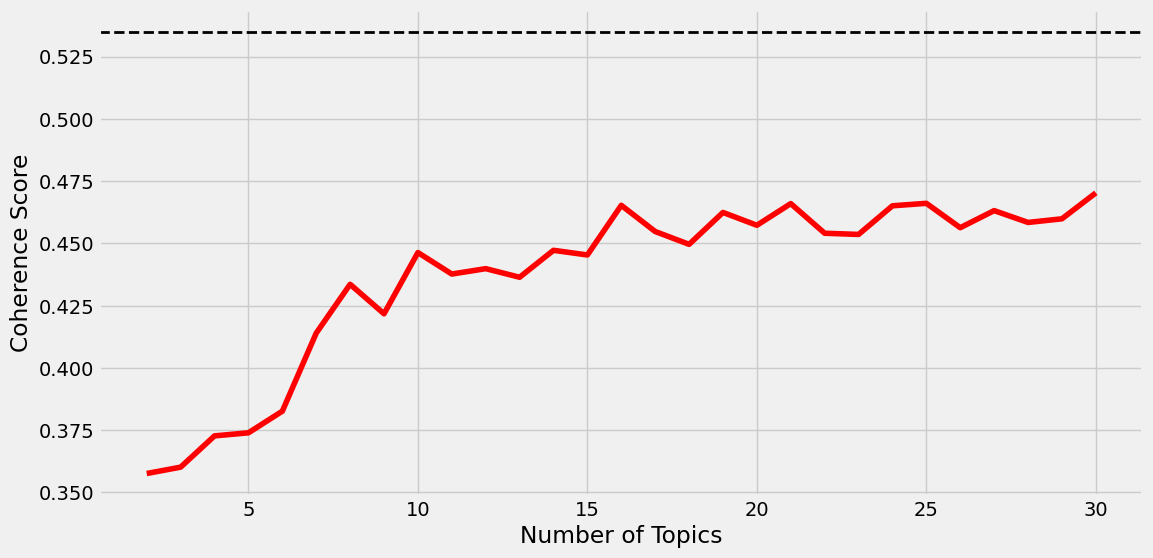

In [45]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

x_ax = range(2, 31, 1)
y_ax = coherence_scores
plt.figure(figsize=(12, 6))
plt.plot(x_ax, y_ax, c='r')
plt.axhline(y=0.535, c='k', linestyle='--', linewidth=2)
plt.rcParams['figure.facecolor'] = 'white'
xl = plt.xlabel('Number of Topics')
yl = plt.ylabel('Coherence Score')

In [47]:
best_model_idx = coherence_df[coherence_df['Number of Topics'] == 20].index[0]
best_lda_model = lda_models[best_model_idx]
best_lda_model.num_topics

20

In [48]:
topics = [[(term, round(wt, 3)) 
               for term, wt in best_lda_model.show_topic(n, topn=20)] 
                   for n in range(0, best_lda_model.num_topics)]

for idx, topic in enumerate(topics):
    print('Topic #'+str(idx+1)+':')
    print([term for term, wt in topic])
    print()

Topic #1:
['algorithm', 'point', 'space', 'data', 'vector', 'problem', 'set', 'method', 'distance', 'cluster', 'kernel', 'constraint', 'function', 'solution', 'clustering', 'transformation', 'number', 'matrix', 'linear', 'dimensional']

Topic #2:
['neuron', 'model', 'input', 'time', 'spike', 'cell', 'synaptic', 'activity', 'firing', 'pattern', 'synapsis', 'neural', 'wa', 'threshold', 'response', 'current', 'rate', 'neuronal', 'firing_rate', 'stimulus']

Topic #3:
['memory', 'bit', 'vector', 'time', 'neural_network', 'number', 'code', 'system', 'pattern', 'network', 'neuron', 'parallel', 'capacity', 'performance', 'processor', 'block', 'connection', 'stored', 'hopfield', 'ha']

Topic #4:
['network', 'input', 'unit', 'output', 'layer', 'weight', 'hidden_unit', 'net', 'pattern', 'architecture', 'activation', 'node', 'neural_network', 'recurrent', 'training', 'connection', 'task', 'module', 'ha', 'wa']

Topic #5:
['signal', 'matrix', 'source', 'information', 'noise', 'linear', 'algorithm',

In [49]:
topics_df = pd.DataFrame([[term for term, wt in topic] 
                              for topic in topics], 
                         columns = ['Term'+str(i) for i in range(1, 21)],
                         index=['Topic '+str(t) for t in range(1, best_lda_model.num_topics+1)]).T
topics_df

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
Term1,algorithm,neuron,memory,network,signal,data,cell,state,classification,probability,rule,equation,model,control,learning,image,function,word,circuit,model
Term2,point,model,bit,input,matrix,method,model,learning,class,variable,representation,dynamic,response,model,weight,object,result,system,chip,data
Term3,space,input,vector,unit,source,set,response,action,training,distribution,structure,system,frequency,system,error,feature,number,speech,output,parameter
Term4,data,time,time,output,information,error,stimulus,algorithm,classifier,algorithm,tree,state,signal,trajectory,algorithm,pixel,bound,recognition,input,prior
Term5,vector,spike,neural_network,layer,noise,prediction,motion,time,wa,approximation,learning,time,stimulus,learning,training,face,class,sequence,current,gaussian
Term6,problem,cell,number,weight,linear,estimate,visual,function,performance,parameter,set,parameter,time,position,problem,view,theorem,model,analog,mixture
Term7,set,synaptic,code,hidden_unit,algorithm,sample,receptive_field,problem,feature,problem,string,case,wa,wa,rate,figure,set,state,voltage,bayesian
Term8,method,activity,system,net,filter,function,map,policy,data,method,symbol,order,system,controller,time,visual,threshold,training,neuron,approach
Term9,distance,firing,pattern,pattern,vector,selection,neuron,step,pattern,term,language,solution,target,movement,function,model,neural_network,hmm,figure,estimate
Term10,cluster,pattern,network,architecture,component,regression,activity,reinforcement_learning,neural_network,node,model,network,auditory,dynamic,parameter,representation,case,wa,system,distribution


In [51]:
pd.set_option('display.max_colwidth', None)
topics_df = pd.DataFrame([', '.join([term for term, wt in topic])  
                              for topic in topics],
                         columns = ['Terms per Topic'],
                         index=['Topic'+str(t) for t in range(1, best_lda_model.num_topics+1)]
                         )
topics_df

,Terms per Topic
Topic1,"algorithm, point, space, data, vector, problem, set, method, distance, cluster, kernel, constraint, function, solution, clustering, transformation, number, matrix, linear, dimensional"
Topic2,"neuron, model, input, time, spike, cell, synaptic, activity, firing, pattern, synapsis, neural, wa, threshold, response, current, rate, neuronal, firing_rate, stimulus"
Topic3,"memory, bit, vector, time, neural_network, number, code, system, pattern, network, neuron, parallel, capacity, performance, processor, block, connection, stored, hopfield, ha"
Topic4,"network, input, unit, output, layer, weight, hidden_unit, net, pattern, architecture, activation, node, neural_network, recurrent, training, connection, task, module, ha, wa"
Topic5,"signal, matrix, source, information, noise, linear, algorithm, filter, vector, component, analysis, data, function, gaussian, entropy, learning, pca, rule, ica, coefficient"
Topic6,"data, method, set, error, prediction, estimate, sample, function, selection, regression, model, problem, result, optimal, distribution, training, based, ensemble, number, query"
Topic7,"cell, model, response, stimulus, motion, visual, receptive_field, map, neuron, activity, spatial, cortical, orientation, direction, pattern, input, unit, figure, cortex, layer"
Topic8,"state, learning, action, algorithm, time, function, problem, policy, step, reinforcement_learning, optimal, system, task, control, environment, based, method, space, result, reward"
Topic9,"classification, class, training, classifier, wa, performance, feature, data, pattern, neural_network, test, set, training_set, trained, number, character, result, task, input, problem"
Topic10,"probability, variable, distribution, algorithm, approximation, parameter, problem, method, term, node, structure, graph, case, xi, set, equation, mean_field, energy, model, iteration"


# Interpreting Topic Model Results

In [52]:
tm_results = best_lda_model[bow_corpus]

In [53]:
corpus_topics = [sorted(topics, key=lambda record: -record[1])[0] 
                     for topics in tm_results]
corpus_topics[:5]

[(2, 0.2300957420005039),
 (1, 0.2502612330198537),
 (15, 0.4206500282007896),
 (7, 0.5831467263808915),
 (14, 0.38100572566591984)]

In [54]:
corpus_topic_df = pd.DataFrame()
corpus_topic_df['Document'] = range(0, len(papers))
corpus_topic_df['Dominant Topic'] = [item[0]+1 for item in corpus_topics]
corpus_topic_df['Contribution %'] = [round(item[1]*100, 2) for item in corpus_topics]
corpus_topic_df['Topic Desc'] = [topics_df.iloc[t[0]]['Terms per Topic'] for t in corpus_topics]
corpus_topic_df['Paper'] = papers

## Dominant Topics Distribution across Corpus

In the following cell, we had to adapt the `.agg()` method call from
```python
topic_stats_df = corpus_topic_df.groupby('Dominant Topic').agg({
                                                'Dominant Topic': {
                                                    'Doc Count': np.size,
                                                    '% Total Docs': np.size }
                                              })
```
to the newer syntax, since nested renamers aren't supported any more by pandas (error: `SpecificationError: nested renamer is not supported`).

In [71]:
pd.set_option('display.max_colwidth', 200)
topic_stats_df = corpus_topic_df.groupby('Dominant Topic')['Dominant Topic'].agg([('Doc Count', np.size), ('% Total Docs', np.size)]).reset_index()
topic_stats_df['% Total Docs'] = topic_stats_df['% Total Docs'].apply(lambda row: round((row*100) / len(papers), 2))
topic_stats_df['Topic Desc'] = [topics_df.iloc[t]['Terms per Topic'] for t in range(len(topic_stats_df))]
topic_stats_df

,Dominant Topic,Doc Count,% Total Docs,Topic Desc
0,1,92,5.29,"algorithm, point, space, data, vector, problem, set, method, distance, cluster, kernel, constraint, function, solution, clustering, transformation, number, matrix, linear, dimensional"
1,2,115,6.61,"neuron, model, input, time, spike, cell, synaptic, activity, firing, pattern, synapsis, neural, wa, threshold, response, current, rate, neuronal, firing_rate, stimulus"
2,3,60,3.45,"memory, bit, vector, time, neural_network, number, code, system, pattern, network, neuron, parallel, capacity, performance, processor, block, connection, stored, hopfield, ha"
3,4,83,4.77,"network, input, unit, output, layer, weight, hidden_unit, net, pattern, architecture, activation, node, neural_network, recurrent, training, connection, task, module, ha, wa"
4,5,64,3.68,"signal, matrix, source, information, noise, linear, algorithm, filter, vector, component, analysis, data, function, gaussian, entropy, learning, pca, rule, ica, coefficient"
5,6,76,4.37,"data, method, set, error, prediction, estimate, sample, function, selection, regression, model, problem, result, optimal, distribution, training, based, ensemble, number, query"
6,7,96,5.52,"cell, model, response, stimulus, motion, visual, receptive_field, map, neuron, activity, spatial, cortical, orientation, direction, pattern, input, unit, figure, cortex, layer"
7,8,102,5.86,"state, learning, action, algorithm, time, function, problem, policy, step, reinforcement_learning, optimal, system, task, control, environment, based, method, space, result, reward"
8,9,85,4.89,"classification, class, training, classifier, wa, performance, feature, data, pattern, neural_network, test, set, training_set, trained, number, character, result, task, input, problem"
9,10,47,2.70,"probability, variable, distribution, algorithm, approximation, parameter, problem, method, term, node, structure, graph, case, xi, set, equation, mean_field, energy, model, iteration"


## Dominant Topics in Specific Research Papers

In [73]:
pd.set_option('display.max_colwidth', 200)
(corpus_topic_df[corpus_topic_df['Document']
                 .isin([681, 9, 392, 1622, 17, 
                        906, 996, 503, 13, 733])])

,Document,Dominant Topic,Contribution %,Topic Desc,Paper
9,9,3,47.80,"memory, bit, vector, time, neural_network, number, code, system, pattern, network, neuron, parallel, capacity, performance, processor, block, connection, stored, hopfield, ha","814 \nNEU1OMO1PHIC NETWORKS BASED \nON SPARSE OPTICAL ORTHOGONAL CODES \nMario P. Vecchi and Jawad A. Salehl \nBell Communications Research \n435 South Street \nMorristown, NJ 07960-1961 \nAbstr..."
13,13,7,56.17,"cell, model, response, stimulus, motion, visual, receptive_field, map, neuron, activity, spatial, cortical, orientation, direction, pattern, input, unit, figure, cortex, layer","701 \nDISCOVERING STRUCTURE FROM MOTION IN \nMONKEY, MAN AND MACHINE \nRalph M. Siegel* \nThe Salk Institute of Biology, La Jolla, Ca. 92037 \nABSTRACT \nThe ability to obtain three-dimensional st..."
17,17,3,43.57,"memory, bit, vector, time, neural_network, number, code, system, pattern, network, neuron, parallel, capacity, performance, processor, block, connection, stored, hopfield, ha","184 \nTHE CAPACITY OF THE KANERVA ASSOCIATIVE MEMORY IS EXPONENTIAL \nP. A. Chou  \nStanford University, Stanford, CA 94305 \nABSTRACT \nThe capacity of an associative memory is defined as the ma..."
392,392,11,67.43,"rule, representation, structure, tree, learning, set, string, symbol, language, model, node, connectionist, level, similarity, sequence, system, wa, figure, number, role","Exploiting Syllable Structure \nin a Connectionist Phonology Model \nDavid S. Touretzky Deirdre W. Wheeler \nSchool of Computer Science \nCarnegie Mellon University \nPittsburgh, PA 15213-3890 \nA..."
503,503,10,21.70,"probability, variable, distribution, algorithm, approximation, parameter, problem, method, term, node, structure, graph, case, xi, set, equation, mean_field, energy, model, iteration","Learning How To Teach \nor \nSelecting Minimal Surface Data \nDavi Geiger \nSiemens Corporate Research, Inc \n755 College Rd. East \nPrinceton, NJ 08540 \nUSA \nRicardo A. Marques Pereira \nDipart..."
681,681,8,73.00,"state, learning, action, algorithm, time, function, problem, policy, step, reinforcement_learning, optimal, system, task, control, environment, based, method, space, result, reward",Memory-based Reinforcement Learning: Efficient \nComputation with Prioritized Sweeping \nAndrew W. Moore \nawmai.mit.edu \nNE43-759 MIT AI Lab. \n545 Technology Square \nCambridge MA 02139 \nChri...
733,733,4,31.31,"network, input, unit, output, layer, weight, hidden_unit, net, pattern, architecture, activation, node, neural_network, recurrent, training, connection, task, module, ha, wa",Emergence of Global Structure from \nLocal Associations \nThea B. Ghiseili-Crippa \nDepartment of Information Science \nUniversity of Pittsburgh \nPittsburgh PA 15260 \nPaul W. Munro \nDepartment ...
906,906,12,17.41,"equation, dynamic, system, state, time, parameter, case, order, solution, network, function, noise, result, attractor, eq, neural_network, ha, theory, matrix, fixed_point","Diffusion of Credit in Markovian Models \nYoshua Bengio* \nDept. I.R.O., Universitd de Montrdal, \nMontreal, Qc, Canada H3C-3J7 \nbengioyIRO. UMontreal. CA \nPaolo Frasconi \nDipartimento di Siste..."
996,996,11,28.97,"rule, representation, structure, tree, learning, set, string, symbol, language, model, node, connectionist, level, similarity, sequence, system, wa, figure, number, role",Adaptive Mixture of Probabilistic Transducers \nYoram Singer \nAT&T Bell Laboratories \nsingerresearch.att.com \nAbstract \nWe introduce and analyze a mixture model for supervised learning of \np...
1622,1622,10,56.26,"probability, variable, distribution, algorithm, approximation, parameter, problem, method, term, node, structure, graph, case, xi, set, equation, mean_field, energy, model, iteration","Approximate inference algorithms for two-layer \nBayesian networks \nAndrew Y. Ng \nComputer Science Division \nUC Berkeley \nBerkeley, CA 94720 \nang @ cs. berkeley. edu \nMichael I. Jordan \n

## Relevant Research Papers per Topic based on Dominance

In [80]:
corpus_topic_df.groupby('Dominant Topic').apply(lambda topic_set: (topic_set.sort_values(by=['Contribution %'],
                                                                                         ascending=False)
                                                                             .iloc[0]), include_groups=False)

,Document,Contribution %,Topic Desc,Paper
Dominant Topic,,,,
1,1715,67.14,"algorithm, point, space, data, vector, problem, set, method, distance, cluster, kernel, constraint, function, solution, clustering, transformation, number, matrix, linear, dimensional","A Geometric Interpretation of v-SVM \nClassifiers \nDavid J. Crisp \nCentre for Sensor Signal and \nInformation Processing, \nDeptartment of Electrical Engineering, \nUniversity of Adelaide, South..."
2,831,82.99,"neuron, model, input, time, spike, cell, synaptic, activity, firing, pattern, synapsis, neural, wa, threshold, response, current, rate, neuronal, firing_rate, stimulus","Dynamic Modulation of Neurons and Networks \nEve Marder \nCenter for Complex Systems \nBrandeis University \nWaltham, MA 02254 USA \nAbstract \nBiological neurons have a variety of intrinsic prope..."
3,56,73.62,"memory, bit, vector, time, neural_network, number, code, system, pattern, network, neuron, parallel, capacity, performance, processor, block, connection, stored, hopfield, ha",804 \nINTRODUCTION TO A SYSTEM FOR IMPLEMENTING NEURAL NET \nCONNECTIONS ON SIMD ARCHITECTURES \nSherryl Tomboulian \nInstitute for Computer Applications in Science and Engineering \nNASA Langley ...
4,537,60.59,"network, input, unit, output, layer, weight, hidden_unit, net, pattern, architecture, activation, node, neural_network, recurrent, training, connection, task, module, ha, wa","Dynamically-Adaptive Winner-Take-All Networks \nTret E. Lange \nComputer Scienos Department \nUniversity of California, Los Angeles, CA 90024 \nAbstract \nWinner-Take-All (WTA) networks, in which..."
5,1311,69.48,"signal, matrix, source, information, noise, linear, algorithm, filter, vector, component, analysis, data, function, gaussian, entropy, learning, pca, rule, ica, coefficient",Learning nonlinear overcomplete \nrepresentations for efficient coding \nMichael S. Lewicki \nlewickisalk. edu \nTerrence J. Sejnowski \nterrysalk. edu \nHoward Hughes Medical Institute \nComputat...
6,1146,70.13,"data, method, set, error, prediction, estimate, sample, function, selection, regression, model, problem, result, optimal, distribution, training, based, ensemble, number, query","Minimizing Statistical Bias with Queries \nDavid A. Cohn \nAdaptive Systems Group \nHarlequin, Inc. \nOne Cambridge Center \nCambridge, MA 02142 \ncohnharlequin. corn \nAbstract \nI describe a qu..."
7,243,78.39,"cell, model, response, stimulus, motion, visual, receptive_field, map, neuron, activity, spatial, cortical, orientation, direction, pattern, input, unit, figure, cortex, layer","92 Cowan and Friedman \nDevelopment and Regeneration of Eye-Brain \nMaps: A Computational Model \nJ.D. Cowan and A.E. Friedman \nDepartment of Mathematics, Committee on \nNeurobiology, and Brain R..."
8,1511,84.25,"state, learning, action, algorithm, time, function, problem, policy, step, reinforcement_learning, optimal, system, task, control, environment, based, method, space, result, reward",The effect of eligibility traces on finding optimal memoryless \npolicies in partially observable Markov decision processes \nJohn Loch \nDepartment of Computer Science \nUniversity of Colorado \n...
9,297,73.61,"classification, class, training, classifier, wa, performance, feature, data, pattern, neural_network, test, set, training_set, trained, number, character, result, task, input, problem","A Comparative Study of the Practical \nCharacteristics of Neural Network and \nConventional Pattern Classifiers \nKenney Ng \nBBN Systems and Technologies \nCambridge, MA 02138 \nAbstract \nRichar..."


# Predicting Topics for New Research Papers

In [82]:
import glob
# papers manually downloaded from NIPS 16
# https://papers.nips.cc/book/advances-in-neural-information-processing-systems-29-2016

new_paper_files = glob.glob('test_data/nips16*.txt')
new_papers = []
for fn in new_paper_files:
    with open(fn, encoding='utf-8', errors='ignore', mode='r+') as f:
        data = f.read()
        new_papers.append(data)
              
print('Total New Papers:', len(new_papers))

Total New Papers: 4


In [83]:
def text_preprocessing_pipeline(documents, normalizer_fn, bigram_model):
    norm_docs = normalizer_fn(documents)
    norm_docs_bigrams = bigram_model[norm_docs]
    return norm_docs_bigrams

def bow_features_pipeline(tokenized_docs, dictionary):
    paper_bow_features = [dictionary.doc2bow(text) 
                              for text in tokenized_docs]
    return paper_bow_features

norm_new_papers = text_preprocessing_pipeline(documents=new_papers, normalizer_fn=normalize_corpus, 
                                              bigram_model=bigram_model)
norm_bow_features = bow_features_pipeline(tokenized_docs=norm_new_papers, dictionary=dictionary)

In [85]:
print(norm_new_papers[0][:30])

['cooperative', 'graphical_model', 'josip', 'djolonga', 'dept_computer', 'science', 'eth', 'zurich', 'josipd', 'inf', 'ethz', 'ch', 'stefanie', 'jegelka', 'csail', 'mit', 'stefje', 'mit_edu', 'sebastian', 'tschiatschek', 'dept_computer', 'science', 'eth', 'zurich', 'stschia', 'inf', 'ethz', 'ch', 'andreas', 'krause']


In [86]:
print(norm_bow_features[0][:30])

[(31, 1), (33, 1), (47, 1), (49, 2), (50, 7), (51, 3), (57, 1), (59, 1), (65, 2), (66, 2), (67, 3), (69, 1), (70, 4), (72, 17), (79, 2), (80, 1), (81, 2), (92, 5), (100, 3), (101, 3), (102, 3), (105, 7), (109, 2), (124, 2), (126, 3), (128, 1), (130, 1), (140, 1), (142, 5), (148, 1)]


In [87]:
def get_topic_predictions(topic_model, corpus, topn=3):
    topic_predictions = topic_model[corpus]
    best_topics = [[(topic, round(wt, 3)) 
                        for topic, wt in sorted(topic_predictions[i], 
                                                key=lambda row: -row[1])[:topn]] 
                            for i in range(len(topic_predictions))]
    return best_topics

In [88]:
topic_preds = get_topic_predictions(topic_model=best_lda_model, 
                                    corpus=norm_bow_features, topn=2)
topic_preds

[[(9, 0.353), (0, 0.16)],
 [(15, 0.236), (1, 0.095)],
 [(7, 0.449), (16, 0.215)],
 [(17, 0.271), (15, 0.187)]]

In [89]:
results_df = pd.DataFrame()
results_df['Papers'] = range(1, len(new_papers)+1)
results_df['Dominant Topics'] = [[topic_num+1 for topic_num, wt in item] for item in topic_preds]
res = results_df.set_index(['Papers'])['Dominant Topics'].apply(pd.Series).stack().reset_index(level=1, drop=True)
results_df = pd.DataFrame({'Dominant Topics': res.values}, index=res.index)
results_df['Contribution %'] = [topic_wt for topic_list in 
                                        [[round(wt*100, 2) 
                                              for topic_num, wt in item] 
                                                 for item in topic_preds] 
                                    for topic_wt in topic_list]

results_df['Topic Desc'] = [topics_df.iloc[t-1]['Terms per Topic'] for t in results_df['Dominant Topics'].values]
results_df['Paper Desc'] = [new_papers[i-1][:200] for i in results_df.index.values]

In [90]:
pd.set_option('display.max_colwidth', 300)
results_df

,Dominant Topics,Contribution %,Topic Desc,Paper Desc
Papers,,,,
1,10,35.3,"probability, variable, distribution, algorithm, approximation, parameter, problem, method, term, node, structure, graph, case, xi, set, equation, mean_field, energy, model, iteration","Cooperative Graphical Models\nJosip Djolonga\nDept. of Computer Science, ETH Zurich ¨\njosipd@inf.ethz.ch\nStefanie Jegelka\nCSAIL, MIT\nstefje@mit.edu\nSebastian Tschiatschek\nDept. of Computer Science, ETH"
1,1,16.0,"algorithm, point, space, data, vector, problem, set, method, distance, cluster, kernel, constraint, function, solution, clustering, transformation, number, matrix, linear, dimensional","Cooperative Graphical Models\nJosip Djolonga\nDept. of Computer Science, ETH Zurich ¨\njosipd@inf.ethz.ch\nStefanie Jegelka\nCSAIL, MIT\nstefje@mit.edu\nSebastian Tschiatschek\nDept. of Computer Science, ETH"
2,16,23.6,"image, object, feature, pixel, face, view, figure, visual, model, representation, based, region, system, point, location, recognition, shape, scale, contour, local","Automated scalable segmentation of neurons from\nmultispectral images\nUygar Sümbül\nGrossman Center for the Statistics of Mind\nand Dept. of Statistics, Columbia University\nDouglas Roossien Jr.\nUniversit"
2,2,9.5,"neuron, model, input, time, spike, cell, synaptic, activity, firing, pattern, synapsis, neural, wa, threshold, response, current, rate, neuronal, firing_rate, stimulus","Automated scalable segmentation of neurons from\nmultispectral images\nUygar Sümbül\nGrossman Center for the Statistics of Mind\nand Dept. of Statistics, Columbia University\nDouglas Roossien Jr.\nUniversit"
3,8,44.9,"state, learning, action, algorithm, time, function, problem, policy, step, reinforcement_learning, optimal, system, task, control, environment, based, method, space, result, reward","PAC Reinforcement Learning with Rich Observations\nAkshay Krishnamurthy\nUniversity of Massachusetts, Amherst\nAmherst, MA, 01003\nakshay@cs.umass.edu\nAlekh Agarwal\nMicrosoft Research\nNew York, NY 10011\na"
3,17,21.5,"function, result, number, bound, class, theorem, set, threshold, neural_network, case, proof, polynomial, size, complexity, linear, approximation, learning, ha, constant, weight","PAC Reinforcement Learning with Rich Observations\nAkshay Krishnamurthy\nUniversity of Massachusetts, Amherst\nAmherst, MA, 01003\nakshay@cs.umass.edu\nAlekh Agarwal\nMicrosoft Research\nNew York, NY 10011\na"
4,18,27.1,"word, system, speech, recognition, sequence, model, state, training, hmm, wa, time, context, speaker, frame, speech_recognition, phoneme, output, feature, neural_network, experiment","Unsupervised Learning of Spoken Language with\nVisual Context\nDavid Harwath, Antonio Torralba, and James R. Glass\nComputer Science and Artificial Intelligence Laboratory\nMassachusetts Institute of Tech"
4,16,18.7,"image, object, feature, pixel, face, view, figure, visual, model, representation, based, region, system, point, location, recognition, shape, scale, contour, local","Unsupervised Learning of Spoken Language with\nVisual Context\nDavid Harwath, Antonio Torralba, and James R. Glass\nComputer Science and Artificial Intelligence Laboratory\nMassachusetts Institute of Tech"
